# Young-Adult Interstate Migration: Policy Incentives, Social Networks, and Capacity Feedback — V8
## A spatial agent-based model with migration chains, housing/job constraints, and robustness tests

**Core question**

> How strong must a geographically targeted housing-and-employment policy be to overcome young adults' social attachment, and when do migration chains and local capacity constraints amplify or offset that response?

This revision adds two forms of robustness requested in the model review: **social-threshold sensitivity** and **network-homophily sensitivity**. It also adds a lagged **rent response to excess housing demand** so housing pressure affects next-year migration utility rather than appearing only as a hard capacity rejection.

The former `happiness` measure is renamed **social utility index**. It is a transparent model-internal composite score, not a validated subjective-well-being survey measure. Its role is diagnostic rather than a real-world welfare ranking.

**V7 review-closure revision.** This version closes the remaining high-priority review comments: mover-level unit consistency, a soft housing-capacity mechanism with lagged rent feedback, a main-horizon ACS move-rate calibration, a wider policy-intensity sweep, an external-competition scope audit using ACS PUMS, a Tulsa Remote monetary-reference diagnostic, and an explicit BRFSS coverage audit. Optional full geography expansion to Oklahoma/West Virginia is deliberately not mixed into the main eight-state model because it would require a new state-space and IRS-route recalibration; it is documented as external-validation future work rather than presented as completed evidence.


### Reproducible results build

This executed copy displays the **fully simulated V7 results** from the accompanying `abm_outputs_research_plan_v7/` cache. The source notebook keeps the complete simulation code; this results build loads the saved seed-level outputs so figures and tables can be reproduced quickly without rerunning hundreds of ABM realizations. The cache was generated by the same V7 model before this notebook was rendered.

In [ ]:
import json
import math
import os
import warnings
import zipfile
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import urlopen

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.stats import t as student_t

try:
    from joblib import Parallel, delayed
    JOBLIB_AVAILABLE = True
except Exception:
    JOBLIB_AVAILABLE = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 170)

RANDOM_SEED = 42
BASE_YEAR = 2026

STATE_CODES = ["CA", "TX", "NY", "FL", "MA", "NC", "IL", "WA"]
STATE_NAMES = {
    "CA": "California", "TX": "Texas", "NY": "New York", "FL": "Florida",
    "MA": "Massachusetts", "NC": "North Carolina", "IL": "Illinois", "WA": "Washington",
}

# Full research design. Reduce these values only for debugging.
BASELINE_AGENTS = 1000
BASELINE_YEARS = 20
BASELINE_SEEDS = list(range(101, 109))

EXPERIMENT_AGENTS = 600
EXPERIMENT_YEARS = 12
CROSS_SEEDS = list(range(201, 209))
SWEEP_SEEDS = list(range(301, 309))
SHOCK_SEEDS = list(range(401, 407))
SENSITIVITY_SEEDS = list(range(501, 505))
CALIBRATION_SEEDS = (901, 902, 903, 904, 905)

N_JOBS = 1  # deterministic final execution; avoids process-backend stalls in notebook kernels
N_AGENTS = BASELINE_AGENTS
N_YEARS = BASELINE_YEARS

POLICY_COLS = [
    "housing_policy",
    "employment_incentive",
    "migration_incentive",
]

SOCIAL_UTILITY_WEIGHTS = {
    "peer": 0.30,
    "coorigin": 0.20,
    "home": 0.10,
    "employment": 0.20,
    "income": 0.10,
    "affordability": 0.10,
}

INTERACTION_COLORS = {
    "weak": "#4C72B0",
    "medium": "#DD8452",
    "strong": "#55A868",
}



def mean_t_ci(series):
    x = np.asarray(pd.Series(series).dropna(), dtype=float)
    if len(x) == 0:
        return np.nan, np.nan
    mean = float(x.mean())
    if len(x) == 1:
        return mean, np.nan
    half = float(
        student_t.ppf(0.975, len(x) - 1)
        * x.std(ddof=1)
        / np.sqrt(len(x))
    )
    return mean, half


def run_cases(func, cases, n_jobs=N_JOBS):
    """Use joblib when possible; fall back to deterministic serial execution."""
    if JOBLIB_AVAILABLE and n_jobs > 1:
        try:
            return Parallel(n_jobs=n_jobs, backend="loky")(
                delayed(func)(*case) for case in cases
            )
        except Exception as exc:
            print("Parallel execution unavailable; using serial fallback:", type(exc).__name__)
    return [func(*case) for case in cases]

print("Environment ready.")

Environment ready.


## 1. Empirical state inputs

In [ ]:
def build_real_state_snapshot():
    raw = pd.DataFrame({
        "state": STATE_CODES,

        "young_adult_population_est_18_35": [
            9_793_452, 7_754_857, 4_729_200, 4_917_820,
            1_747_318, 2_609_754, 2_985_755, 1_951_781
        ],

        "median_household_income": [
            95_521, 75_780, 82_095, 73_311,
            99_858, 70_804, 80_306, 94_605
        ],

        "median_gross_rent_monthly": [
            1_992, 1_413, 1_561, 1_719,
            1_757, 1_245, 1_238, 1_731
        ],

        "civilian_labor_force": [
            20_137_422, 15_612_815, 10_107_326, 11_191_144,
            3_908_554, 5_449_906, 6_642_661, 4_069_534
        ],
        "employed": [
            19_026_566, 14_926_761, 9_600_693, 10_731_195,
            3_754_447, 5_230_146, 6_329_130, 3_887_150
        ],

        "bachelor_plus_share_25plus": [
            0.3748778859, 0.3424161436, 0.4063985602, 0.3491620625,
            0.4778163562, 0.3679334714, 0.3827775836, 0.4045106716
        ],

        "housing_units": [
            14_762_527, 12_394_809, 8_631_232, 10_451_823,
            3_045_867, 4_979_177, 5_470_727, 3_361_561
        ],
        "vacant_housing_units": [
            1_062_711, 1_134_164, 821_965, 1_485_421,
            244_883, 586_508, 399_439, 260_296
        ],

        "ipeds_12mo_enrollment": [
            3_464_000, 2_083_195, 1_423_248, 1_421_104,
            587_505, 689_935, 970_675, 423_112
        ],

        "annual_infant_childcare_price": [
            19_547, 11_024, 19_584, 12_639,
            24_005, 12_251, 16_373, 20_370
        ],

        "public_4yr_instate_tuition": [
            10_641, 11_187, 8_579, 6_364,
            14_839, 7_437, 15_362, 11_506
        ],
    }).set_index("state")

    raw["employment_rate_labor_force"] = (
        raw["employed"] / raw["civilian_labor_force"]
    )
    raw["vacancy_rate"] = (
        raw["vacant_housing_units"] / raw["housing_units"]
    )
    raw["ipeds_enrollment_per_young_adult"] = (
        raw["ipeds_12mo_enrollment"]
        / raw["young_adult_population_est_18_35"]
    )
    return raw

real_raw_data = build_real_state_snapshot()

In [ ]:
def mean_index(series):
    x = series.astype(float)
    return x / x.mean()

def prepare_state_data(raw):
    df = raw.copy()

    df["youth_pop_weight"] = mean_index(
        df["young_adult_population_est_18_35"]
    )
    df["wage_index"] = mean_index(df["median_household_income"])
    df["rent_index"] = mean_index(df["median_gross_rent_monthly"])
    df["job_index"] = mean_index(df["employment_rate_labor_force"])
    df["education_access_index"] = mean_index(
        df["ipeds_enrollment_per_young_adult"]
    )
    df["tuition_index"] = mean_index(df["public_4yr_instate_tuition"])
    df["childcare_cost_index"] = mean_index(
        df["annual_infant_childcare_price"]
    )
    df["housing_capacity_index"] = mean_index(df["vacancy_rate"])
    df["college_share_proxy"] = df["bachelor_plus_share_25plus"]

    return df

state_data = prepare_state_data(real_raw_data)

## 2. Spatial environment and IRS route calibration

In [ ]:
STATE_COORDS = {
    "CA": (36.8, -119.4),
    "TX": (31.0, -99.9),
    "NY": (42.9, -75.5),
    "FL": (27.8, -81.7),
    "MA": (42.3, -71.8),
    "NC": (35.5, -79.4),
    "IL": (40.0, -89.2),
    "WA": (47.4, -120.7),
}

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp = np.radians(lat2 - lat1)
    dl = np.radians(lon2 - lon1)
    a = (
        np.sin(dp / 2) ** 2
        + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    )
    return 2 * R * np.arcsin(np.sqrt(a))

distance_km = pd.DataFrame(
    index=STATE_CODES, columns=STATE_CODES, dtype=float
)

for s1 in STATE_CODES:
    for s2 in STATE_CODES:
        distance_km.loc[s1, s2] = haversine_km(
            *STATE_COORDS[s1], *STATE_COORDS[s2]
        )

distance_index = distance_km / distance_km.to_numpy().max()

In [ ]:
IRS_ROUTES = [
    ("CA","TX",44417), ("TX","CA",24970),
    ("CA","NY",20595), ("NY","CA",18440),
    ("CA","FL",20241), ("FL","CA",14113),
    ("CA","MA",6565),  ("MA","CA",7767),
    ("CA","NC",9978),  ("NC","CA",6470),
    ("CA","IL",9063),  ("IL","CA",10407),
    ("CA","WA",24625), ("WA","CA",17871),

    ("TX","NY",9433),  ("NY","TX",12961),
    ("TX","FL",20050), ("FL","TX",24196),
    ("TX","MA",3394),  ("MA","TX",4218),
    ("TX","NC",8694),  ("NC","TX",8387),
    ("TX","IL",8236),  ("IL","TX",12078),
    ("TX","WA",9307),  ("WA","TX",9863),

    ("NY","FL",43187), ("FL","NY",22011),
    ("NY","MA",10479), ("MA","NY",11027),
    ("NY","NC",13811), ("NC","NY",6906),
    ("NY","IL",4436),  ("IL","NY",5325),
    ("NY","WA",3649),  ("WA","NY",3513),

    ("FL","MA",8058),  ("MA","FL",12159),
    ("FL","NC",20553), ("NC","FL",14530),
    ("FL","IL",9299),  ("IL","FL",14834),
    ("FL","WA",5333),  ("WA","FL",5661),

    ("MA","NC",3483),  ("NC","MA",2213),
    ("NC","WA",2371),  ("WA","NC",2464),
    ("IL","WA",2734),  ("WA","IL",2158),
]

irs_flows = pd.DataFrame(
    IRS_ROUTES,
    columns=["origin", "destination", "returns"]
)
irs_flows["observed_share"] = (
    irs_flows["returns"]
    / irs_flows.groupby("origin")["returns"].transform("sum")
)

irs_flow_matrix = (
    irs_flows.pivot(
        index="origin", columns="destination", values="returns"
    )
    .reindex(index=STATE_CODES, columns=STATE_CODES)
)

for s in STATE_CODES:
    irs_flow_matrix.loc[s, s] = np.nan

In [ ]:
STATE_POS = {s: i for i, s in enumerate(STATE_CODES)}

PRIOR_BETA = np.array([
    1.10,  # income
    1.25,  # jobs
    1.00,  # rent
    0.20,  # distance
    0.45,  # education
    0.50,  # childcare
], dtype=float)

PRIOR_SCALE = np.array([1.0, 1.0, 1.0, 0.5, 0.5, 0.5])
CALIBRATION_TEMPERATURE = 0.85

def calibration_features():
    return {
        "log_income": np.log(
            state_data["wage_index"].to_numpy()
        ),
        "jobs": state_data["job_index"].to_numpy(),
        "rent": state_data["rent_index"].to_numpy(),
        "education": state_data[
            "education_access_index"
        ].to_numpy(),
        "childcare": (
            1.0
            / state_data["childcare_cost_index"]
        ).to_numpy(),
    }

CAL_FEATURES = calibration_features()

def predicted_route_shares(theta, origins):
    """
    Deterministic expected route shares.

    Rather than representing each origin with one average person,
    the calibration mixes four composition groups:
      college / non-college × child / no-child.

    This better matches the heterogeneous utility function used in
    the ABM while keeping calibration deterministic.
    """
    beta = theta[:6]
    destination_effect = np.r_[0.0, theta[6:]]

    rows = []

    for origin in origins:
        observed = irs_flows[
            irs_flows["origin"] == origin
        ].copy()
        destinations = observed[
            "destination"
        ].tolist()

        college_share = float(
            state_data.loc[
                origin, "college_share_proxy"
            ]
        ) * 0.82
        college_share = float(
            np.clip(college_share, 0.05, 0.70)
        )

        child_share = 0.25

        mixture_probability = np.zeros(
            len(destinations), dtype=float
        )

        for college, college_weight in [
            (0, 1.0 - college_share),
            (1, college_share),
        ]:
            for has_child, child_weight in [
                (0, 1.0 - child_share),
                (1, child_share),
            ]:
                utility = []

                for destination in destinations:
                    d = STATE_POS[destination]

                    u = (
                        beta[0]
                        * CAL_FEATURES[
                            "log_income"
                        ][d]
                        + beta[1]
                        * CAL_FEATURES[
                            "jobs"
                        ][d]
                        - beta[2]
                        * CAL_FEATURES[
                            "rent"
                        ][d]
                        - beta[3]
                        * distance_index.loc[
                            origin, destination
                        ]
                        + beta[4]
                        * (1 - college)
                        * CAL_FEATURES[
                            "education"
                        ][d]
                        + beta[5]
                        * has_child
                        * CAL_FEATURES[
                            "childcare"
                        ][d]
                        + destination_effect[d]
                    )
                    utility.append(u)

                utility = (
                    np.asarray(utility)
                    / CALIBRATION_TEMPERATURE
                )
                p = np.exp(
                    utility - utility.max()
                )
                p /= p.sum()

                mixture_probability += (
                    college_weight
                    * child_weight
                    * p
                )

        mixture_probability /= (
            mixture_probability.sum()
        )

        for (_, row), pred in zip(
            observed.iterrows(),
            mixture_probability,
        ):
            rows.append({
                "origin": origin,
                "destination": row[
                    "destination"
                ],
                "returns": row["returns"],
                "observed_share": row[
                    "observed_share"
                ],
                "predicted_share": pred,
            })

    return pd.DataFrame(rows)

def calibration_loss(
    theta,
    origins,
    lambda_beta=0.02,
    lambda_fe=0.05,
):
    comp = predicted_route_shares(
        theta, origins
    )

    weights = np.sqrt(
        comp["returns"].to_numpy()
    )
    sq_error = (
        comp["predicted_share"]
        - comp["observed_share"]
    ) ** 2

    fit_loss = np.average(
        sq_error, weights=weights
    )

    beta_penalty = lambda_beta * np.mean(
        (
            (theta[:6] - PRIOR_BETA)
            / PRIOR_SCALE
        ) ** 2
    )
    fe_penalty = (
        lambda_fe
        * np.mean(theta[6:] ** 2)
    )

    return float(
        fit_loss
        + beta_penalty
        + fe_penalty
    )

def route_fit_metrics(theta, origins):
    comp = predicted_route_shares(
        theta, origins
    )
    w = np.sqrt(
        comp["returns"].to_numpy()
    )

    error = (
        comp["predicted_share"]
        - comp["observed_share"]
    )

    rmse = np.sqrt(
        np.average(
            error ** 2,
            weights=w,
        )
    )
    mae = np.average(
        np.abs(error),
        weights=w,
    )

    if (
        comp[
            "predicted_share"
        ].std()
        > 0
    ):
        corr = np.corrcoef(
            comp["observed_share"],
            comp["predicted_share"],
        )[0, 1]
    else:
        corr = np.nan

    return {
        "weighted_rmse": float(rmse),
        "weighted_mae": float(mae),
        "correlation": float(corr),
    }

x0 = np.r_[
    PRIOR_BETA,
    np.zeros(7),
]

bounds = (
    [
        (0.0, 4.0),
        (0.0, 4.0),
        (0.0, 4.0),
        (0.0, 3.0),
        (0.0, 2.0),
        (0.0, 2.0),
    ]
    + [(-2.0, 2.0)] * 7
)

TRAIN_ORIGINS = [
    "CA", "TX", "NY",
    "FL", "MA", "NC",
]
VALIDATION_ORIGINS = [
    "IL", "WA",
]

train_result = minimize(
    calibration_loss,
    x0,
    args=(TRAIN_ORIGINS,),
    method="L-BFGS-B",
    bounds=bounds,
    options={"maxiter": 500},
)

validation_table = pd.DataFrame([
    {
        "model": "Prior specification",
        "sample": "train",
        **route_fit_metrics(
            x0, TRAIN_ORIGINS
        ),
    },
    {
        "model": "Calibrated on train",
        "sample": "train",
        **route_fit_metrics(
            train_result.x,
            TRAIN_ORIGINS,
        ),
    },
    {
        "model": "Prior specification",
        "sample": "holdout",
        **route_fit_metrics(
            x0,
            VALIDATION_ORIGINS,
        ),
    },
    {
        "model": "Calibrated on train",
        "sample": "holdout",
        **route_fit_metrics(
            train_result.x,
            VALIDATION_ORIGINS,
        ),
    },
])

In [ ]:
final_calibration = minimize(
    calibration_loss,
    x0,
    args=(STATE_CODES,),
    method="L-BFGS-B",
    bounds=bounds,
    options={"maxiter": 700},
)

CALIBRATED_BETA = final_calibration.x[:6].copy()
DESTINATION_EFFECTS = pd.Series(
    np.r_[0.0, final_calibration.x[6:]],
    index=STATE_CODES,
    name="destination_effect",
)

final_route_metrics = route_fit_metrics(
    final_calibration.x, STATE_CODES
)

print("IRS calibration / holdout validation")
display(validation_table.round(3))
print("Final all-route correlation:", round(final_route_metrics["correlation"], 3))

IRS calibration / holdout validation


,model,sample,weighted_rmse,weighted_mae,correlation
0,Prior specification,train,0.113,0.090,-0.143
1,Calibrated on train,train,0.083,0.066,0.705
2,Prior specification,holdout,0.134,0.109,-0.034
3,Calibrated on train,holdout,0.116,0.092,0.589


Final all-route correlation: 0.693


### Spatial view of the empirical eight-state migration system

The model is spatial rather than a collection of abstract rows. The figure below places the eight states at approximate geographic coordinates, sizes nodes by the young-adult population proxy, and draws the largest observed IRS interstate routes. This is a descriptive data figure, not a simulated map.

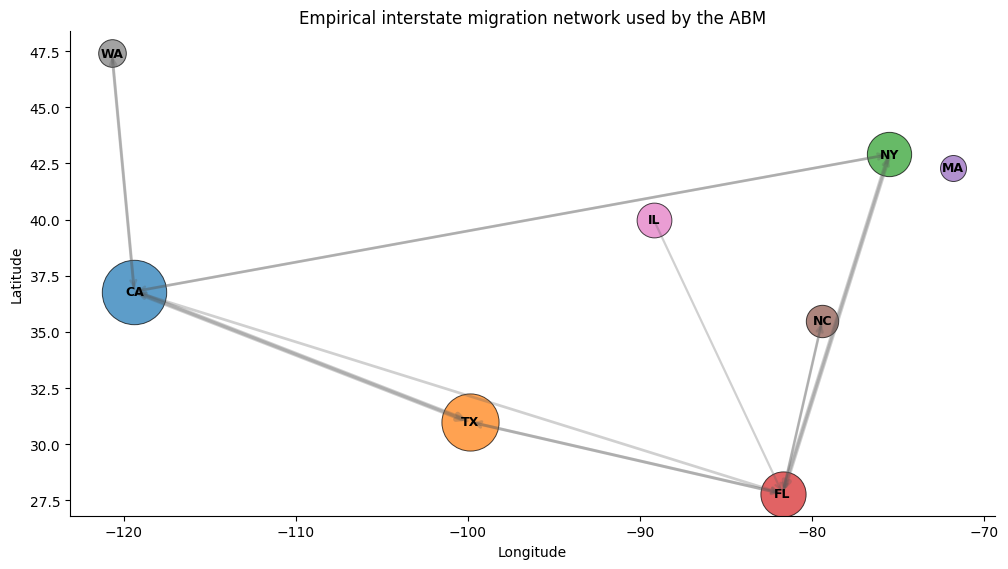

In [ ]:
# Real-world spatial presentation of the empirical migration network.
top_routes = irs_flows.nlargest(14, "returns").copy()
max_flow = top_routes["returns"].max()
pop = state_data["young_adult_population_est_18_35"]
pop_size = 350 + 1800 * (pop - pop.min()) / max(pop.max() - pop.min(), 1)

fig, ax = plt.subplots(figsize=(10.2, 5.8))
for _, row in top_routes.iterrows():
    o, d = row["origin"], row["destination"]
    y1, x1 = STATE_COORDS[o]
    y2, x2 = STATE_COORDS[d]
    lw = 0.6 + 3.0 * row["returns"] / max_flow
    ax.annotate(
        "", xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", lw=lw, alpha=0.28, color="0.35"),
    )

for state in STATE_CODES:
    lat, lon = STATE_COORDS[state]
    ax.scatter(lon, lat, s=pop_size[state], alpha=0.72, edgecolor="black", linewidth=0.7)
    ax.text(lon, lat, state, ha="center", va="center", fontsize=9, fontweight="bold")

ax.set_title("Empirical interstate migration network used by the ABM")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()